## imports and defalt

In [1]:
import pygama
print(pygama.__version__)
print(pygama.__file__)

import pygama.pargen.survival_fractions as sf
print(dir(sf))

2.6.1
/mnt/atlas02/users/leoli/.conda/envs/leolienv/lib/python3.13/site-packages/pygama/__init__.py
['Minuit', 'ValueView', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'annotations', 'compton_sf', 'compton_sf_sweep', 'copy', 'cost', 'energy_guess', 'fail_pdf_gos', 'fail_pdf_hpge', 'fix_all_but_nevents', 'gauss_on_step', 'get_bounds', 'get_sf_sweep', 'get_survival_fraction', 'hpge_peak', 'log', 'logging', 'np', 'pass_pdf_gos', 'pass_pdf_hpge', 'pd', 'pgc', 'plt', 'update_guess']


In [2]:
# 如果需要，可取消注释并改成你的路径
import sys
sys.path.append(r'/mnt/atlas02/users/leoli/AoverE_analysis/low_cuts/')

from importlib import reload
import os
from weakref import ref
import low_cut_utils_modified as ref 
reload(ref)
from low_cut_utils_modified import *
import numpy as np
from lgdo import lh5
import numpy as np
import awkward as ak
from lgdo import lh5
import pandas as pd
import matplotlib.pyplot as plt


/tmp/ipykernel_2416227/3447005164.py:12: DeprecationWarning: lgdo.lh5 has moved to its own package, legend-lh5io. Please replace 'import lgdo.lh5' with 'import lh5'. lgdo.lh5 will be removed in a future release.
  from lgdo import lh5


In [ ]:
sf.get_survival_fraction

In [3]:
filepath = "/mnt/atlas02/users/leoli/scarf/sp01/data/hit_vcs"
files = os.listdir(filepath)
files.sort()
files

pnum_cal = "00"
run_cal = "037"

pnum_phy_bg = "00"
run_phy_bg = "038"

pnum_phy_signal = "05"
run_phy_signal = "059"

runs = [
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7',
    's300ns_mw1', 's300ns_mw3', 's300ns_mw5', 's300ns_mw7','s300ns_mw15',
    's500ns_mw1', 's500ns_mw3', 's500ns_mw5', 's500ns_mw7','s500ns_mw15',
    's700ns_mw1', 's700ns_mw3', 's700ns_mw5', 's700ns_mw7','s700ns_mw15',
    's1000ns_mw1',  's1000ns_mw3',  's1000ns_mw5',  's1000ns_mw7','s1000ns_mw15',
    's2000ns_mw3',  's2000ns_mw5',  's2000ns_mw7',
]

def build_run_db(runs, filepath):
    db = {}
    missing = []

    for run in runs:
        m = re.match(r"s(\d+)ns_mw(\d+)", run)
        if not m:
            missing.append(f"{run}: invalid run name format")
            continue

        run_path = os.path.join(filepath, run)
        phy_bg_path = os.path.join(run_path, "phy", f"p{pnum_phy_bg}", f"r{run_phy_bg}")
        phy_signal_path = os.path.join(run_path, "phy", f"p{pnum_phy_signal}", f"r{run_phy_signal}")
        cal_path = os.path.join(run_path, "cal", f"p{pnum_cal}", f"r{run_cal}")

        missing_this_run = []

        if not os.path.exists(run_path):
            missing_this_run.append(f"run folder missing: {run_path}")
        if not os.path.exists(phy_bg_path):
            missing_this_run.append(f"phy_bg path missing: {phy_bg_path}")
        if not os.path.exists(phy_signal_path):
            missing_this_run.append(f"phy_signal path missing: {phy_signal_path}")
        if not os.path.exists(cal_path):
            missing_this_run.append(f"cal path missing: {cal_path}")

        if missing_this_run:
            missing.append(f"{run}\n  " + "\n  ".join(missing_this_run))
            continue

        phy_bg_files = sorted(os.listdir(phy_bg_path))
        phy_signal_files = sorted(os.listdir(phy_signal_path))
        cal_files = sorted(os.listdir(cal_path))

        db[run] = {
            "run": run,
            "interval": f"{m.group(1)}ns",
            "mw": f"mw{m.group(2)}",

            "phy_bg_path": phy_bg_path,
            "phy_signal_path": phy_signal_path,
            "cal_path": cal_path,

            "phy_bg_files": phy_bg_files,
            "phy_signal_files": phy_signal_files,
            "cal_files": cal_files,

            "phy_bg_pathlist": [os.path.join(phy_bg_path, f) for f in phy_bg_files],
            "phy_signal_pathlist": [os.path.join(phy_signal_path, f) for f in phy_signal_files],
            "cal_pathlist": [os.path.join(cal_path, f) for f in cal_files],
        }

    if missing:
        raise FileNotFoundError(
            "[ERROR] Some runs or paths are missing:\n\n" + "\n\n".join(missing)
        )

    return db
run_db = build_run_db(runs, filepath)

## sideband

In [ ]:
preferred_run = 's100ns_mw5'
run_db = build_run_db(runs, filepath)
if preferred_run in run_db:
    test_run = preferred_run
else:
    test_run = sorted(run_db.keys())[0]

info = run_db[test_run]
print('test_run =', test_run)
print('interval =', info['interval'])

In [ ]:
E_cal = safe_lh5_read(lh5,"ch002/hit",run_db['s100ns_mw1']['cal_pathlist'])['trapEftp_fix_cal']
dep_fit = find_peak_with_fit(
    arr=E_cal,                     # calibration energy array
    search_range=(1540, 1645),     # DEP 区域
    do_plot=True,
    window_nsigma=4.5,
    # window_nsigma =3, 
    title="DEP fit test"
)

print("DEP mu:", dep_fit["peak_center"])
print("DEP sigma:", dep_fit["sigma"])
print("DEP window:", dep_fit.get("window_bounds", "not defined"))

In [4]:
aoe_field = 'A_max_mw_o_E_fix_Classifier'
low_cut_field = 'A_max_mw_o_E_fix_Low_Cut'
energy_field = 'trapEftp_fix_cal'
run = 's100ns_mw5'
index = 1   # ch001 -> 0, ch002 -> 1

In [ ]:
run = 's100ns_mw5'
energy_array = np.asarray(safe_lh5_read(lh5,"ch002/hit",run_db[run]['cal_pathlist'])[energy_field])
aoe_array = np.asarray(safe_lh5_read(lh5,"ch002/hit",run_db[run]['cal_pathlist'])[aoe_field])
is_valid_waveform= np.asarray(safe_lh5_read(lh5,"ch002/hit",run_db[run]['cal_pathlist'])['is_valid_waveform'])

import numpy as np



In [ ]:
print(len(energy_array), len(aoe_array), len(is_valid_waveform))

## pygama

In [5]:
import numpy as np
import pygama.pargen.energy_cal as pgc
import pygama.pargen.survival_fractions as sf

aoe_field = 'A_max_mw_o_E_fix_Classifier'
low_cut_field = 'A_max_mw_o_E_fix_Low_Cut'
energy_field = 'trapEftp_fix_cal'
run = 's100ns_mw5'
energy_array = np.asarray(safe_lh5_read(lh5,"ch002/hit",run_db[run]['cal_pathlist'])[energy_field])
aoe_array = np.asarray(safe_lh5_read(lh5,"ch002/hit",run_db[run]['cal_pathlist'])[aoe_field])
is_valid_waveform= np.asarray(safe_lh5_read(lh5,"ch002/hit",run_db[run]['cal_pathlist'])['is_valid_waveform'])


In [6]:

fitrange_dep = (1565, 1615)
peak_dep = 1592.5


mask_dep = (
    np.isfinite(energy_array)
    & np.isfinite(aoe_array)
    & (energy_array > fitrange_dep[0])
    & (energy_array < fitrange_dep[1])
    & is_valid_waveform)

E_fit_dep = energy_array[mask_dep]
aoe_fit_dep = aoe_array[mask_dep]

print("E_fit_dep:", len(E_fit_dep))
print("aoe_fit_dep:", len(aoe_fit_dep))


fitrange_sep = (2070, 2140)

peak_sep =2103.5


mask_sep = (
    np.isfinite(energy_array)
    & np.isfinite(aoe_array)
    & (energy_array > fitrange_sep[0])
    & (energy_array < fitrange_sep[1])
    & is_valid_waveform
)

E_fit_sep = energy_array[mask_sep]
aoe_fit_sep = aoe_array[mask_sep]

fitrange_fep =  (2580, 2645)
peak_fep = 2614.5
mask_fep = (
    np.isfinite(energy_array)
    & np.isfinite(aoe_array)
    & (energy_array > fitrange_fep[0])
    & (energy_array < fitrange_fep[1])
    & is_valid_waveform
)
E_fit_fep = energy_array[mask_fep]
aoe_fit_fep = aoe_array[mask_fep] 


E_fit_dep: 9144
aoe_fit_dep: 9144


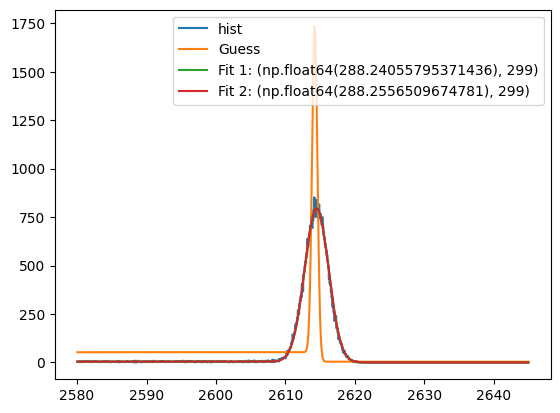

<ValueView x_lo=2580.0 x_hi=2644.9999999999995 n_sig=35194.76401521285 mu=2614.4891436207813 sigma=1.719469668920117 n_bkg=1603.236213698256 hstep=-0.9093873962751742>
<ErrorView x_lo=25.8 x_hi=26.449999999999996 n_sig=188.5200191165095 mu=0.009337047904637075 sigma=0.006842949709608082 n_bkg=44.14379444332587 hstep=0.012498490817559382>
returned cs = (np.float64(288.24055795371436), 299)
returned valid = True
returned values:


In [7]:
pars, errs, cov, cs, func_used, mask_fit, valid, minuit_obj = pgc.unbinned_staged_energy_fit(
    E_fit_fep,
    sf.gauss_on_step,          # or sf.hpge_peak
    guess_func=sf.energy_guess,
    bounds_func=sf.get_bounds,
    # guess_kwargs={"peak": peak, "eres": eres_pars},
    fit_range=fitrange_fep,
    display=2,
)
print(pars)
print(errs)
print("returned cs =", cs)
print("returned valid =", valid)
print("returned values:")


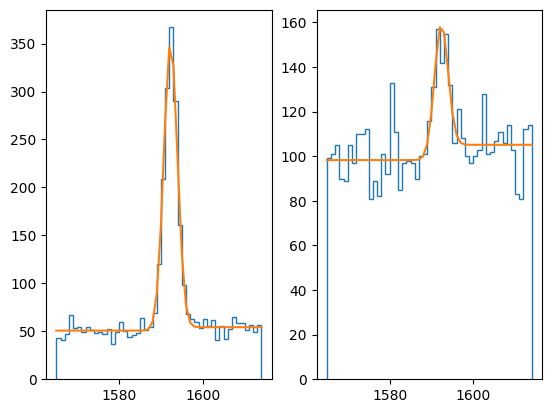

survival fraction dep = 83.85216736419389
survival fraction error = 1.6730139922279563


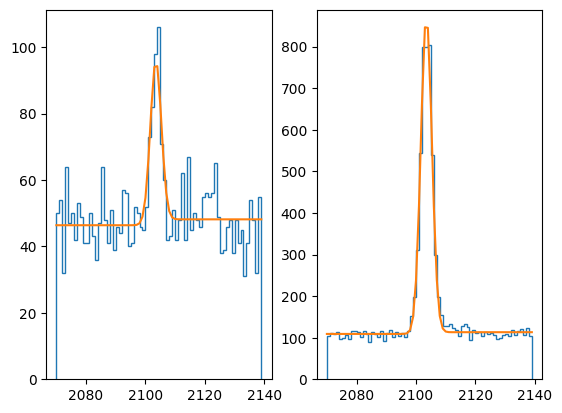

survival fraction sep= 6.001978842344518
survival fraction error = 0.6061525392499365


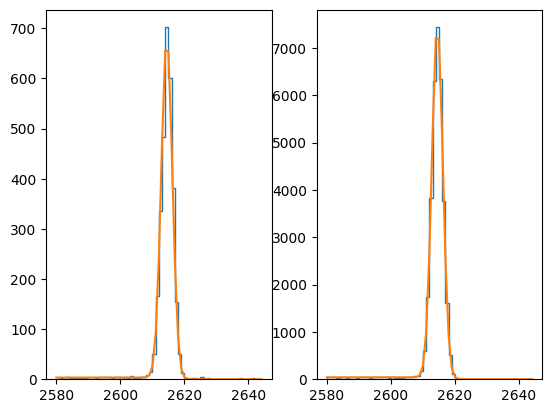

survival fraction fep= 8.34336066362314
survival fraction error = 0.14804765522243649


In [8]:
import pygama.pargen.survival_fractions as sf
# from pygama.math.functions import gauss_on_step
cut_value = -1.115
sf_val_dep, sf_err_dep, values_dep, errors_dep = sf.get_survival_fraction(
    energy=E_fit_dep,
    cut_param=aoe_fit_dep,
    cut_val=cut_value,
    peak=peak_dep,        # DEP peak
    fit_range=fitrange_dep,
    func=sf.gauss_on_step,
    mode="greater",
    display=2,
    eres_pars=3
)
print("survival fraction dep =", sf_val_dep)
print("survival fraction error =", sf_err_dep)

sf_val_sep, sf_err_sep, values_sep, errors_sep = sf.get_survival_fraction(
    energy=E_fit_sep,
    cut_param=aoe_fit_sep,
    cut_val=cut_value,      
    peak=peak_sep,        # SEP peak
    fit_range=fitrange_sep,
    func=sf.hpge_peak,
    mode="greater",
    display=2,
    eres_pars=3
)
print("survival fraction sep=", sf_val_sep)
print("survival fraction error =", sf_err_sep) 

sf_val_fep, sf_err_fep, values_fep, errors_fep = sf.get_survival_fraction(
    energy=E_fit_fep,
    cut_param=aoe_fit_fep,
    cut_val=cut_value,      
    peak=peak_fep,        # FEP peak
    fit_range=fitrange_fep,
    func=sf.hpge_peak,
    mode="greater",
    display=2,
    eres_pars=3
)
print("survival fraction fep=", sf_val_fep)
print("survival fraction error =", sf_err_fep)    

## find cut values

In [ ]:
import numpy as np

target_sf = 90

cut_low = -4.0
cut_high = 0.0

tol = 1e-3          # survival fraction tolerance
max_iter = 30


def eval_dep_sf(cut_value, display=0):
    sf_val_dep, sf_err_dep, values_dep, errors_dep = sf.get_survival_fraction(
        energy=E_fit_dep,
        cut_param=aoe_fit_dep,
        cut_val=cut_value,
        peak=peak_dep,
        fit_range=fitrange_dep,
        func=sf.hpge_peak,
        mode="greater",
        display=display,
        eres_pars=3,
    )
    return sf_val_dep, sf_err_dep, values_dep, errors_dep

# check endpoints
sf_low, _, _, _ = eval_dep_sf(cut_low, display=0)
sf_high, _, _, _ = eval_dep_sf(cut_high, display=0)

print("sf at cut_low =", cut_low, ":", sf_low)
print("sf at cut_high =", cut_high, ":", sf_high)

# For mode="greater":
# larger cut_value usually means stricter cut, so survival fraction decreases.
# Therefore sf(cut_low) should be larger than sf(cut_high).
if not (sf_low >= target_sf >= sf_high):
    raise ValueError(
        f"Target survival {target_sf} is not bracketed. "
        f"sf({cut_low})={sf_low}, sf({cut_high})={sf_high}"
    )


best = None

for i in range(max_iter):
    cut_mid = 0.5 * (cut_low + cut_high)

    sf_mid, sf_err_mid, values_mid, errors_mid = eval_dep_sf(cut_mid, display=0)

    diff = sf_mid - target_sf

    print(
        f"iter {i:02d}: "
        f"cut = {cut_mid:.6f}, "
        f"sf = {sf_mid:.6f}, "
        f"diff = {diff:+.6f}"
    )

    best = {
        "cut_value": cut_mid,
        "sf_val_dep": sf_mid,
        "sf_err_dep": sf_err_mid,
        "values_dep": values_mid,
        "errors_dep": errors_mid,
    }

    if abs(diff) < tol:
        break

    # mode="greater": increasing cut_value lowers survival
    if sf_mid > target_sf:
        cut_low = cut_mid
    else:
        cut_high = cut_mid


cut_value_90 = best["cut_value"]

print("\nBest cut value:")
print("cut_value_90 =", cut_value_90)
print("sf_val_dep  =", best["sf_val_dep"])
print("sf_err_dep  =", best["sf_err_dep"])

In [9]:
cal_data_by_run = {}

for run in runs:
    print(f"Processing {run} ...")

    hit = safe_lh5_read(
        lh5,
        "ch002/hit",
        run_db[run]["cal_pathlist"]
    )

    energy_array = np.asarray(hit[energy_field])
    aoe_array = np.asarray(hit[aoe_field])
    is_valid_waveform = np.asarray(hit["is_valid_waveform"]).astype(bool)

    cal_data_by_run[run] = {
        "energy_array": energy_array,
        "aoe_array": aoe_array,
        "is_valid_waveform": is_valid_waveform,
    }

    print(
        run,
        "energy:", energy_array.shape,
        "aoe:", aoe_array.shape,
        "valid:", is_valid_waveform.shape,
    )
    gc.collect()  # free memory after each run

Processing s100ns_mw1 ...
s100ns_mw1 energy: (2292780,) aoe: (2292780,) valid: (2292780,)
Processing s100ns_mw3 ...
s100ns_mw3 energy: (2292780,) aoe: (2292780,) valid: (2292780,)
Processing s100ns_mw5 ...
s100ns_mw5 energy: (2292780,) aoe: (2292780,) valid: (2292780,)
Processing s100ns_mw7 ...
s100ns_mw7 energy: (2292780,) aoe: (2292780,) valid: (2292780,)
Processing s200ns_mw1 ...
s200ns_mw1 energy: (2292780,) aoe: (2292780,) valid: (2292780,)
Processing s200ns_mw3 ...
s200ns_mw3 energy: (2292780,) aoe: (2292780,) valid: (2292780,)
Processing s200ns_mw5 ...
s200ns_mw5 energy: (2292780,) aoe: (2292780,) valid: (2292780,)
Processing s200ns_mw7 ...
s200ns_mw7 energy: (2292780,) aoe: (2292780,) valid: (2292780,)
Processing s60ns_mw1 ...
s60ns_mw1 energy: (2292780,) aoe: (2292780,) valid: (2292780,)
Processing s60ns_mw3 ...
s60ns_mw3 energy: (2292780,) aoe: (2292780,) valid: (2292780,)
Processing s60ns_mw5 ...
s60ns_mw5 energy: (2292780,) aoe: (2292780,) valid: (2292780,)
Processing s60ns

In [ ]:
def get_sf_from_run(run,max_iter=30, tol=1e-3):
    print(f"Calculating survival fraction for {run} ...")
    data = cal_data_by_run[run]
    energy_array = data["energy_array"]
    aoe_array = data["aoe_array"]
    is_valid_waveform = data["is_valid_waveform"]
    fitrange_dep = (1565, 1615)
    peak_dep = 1592.5
    mask_dep = (
        np.isfinite(energy_array)
        & np.isfinite(aoe_array)
        & (energy_array > fitrange_dep[0])
        & (energy_array < fitrange_dep[1])
        & is_valid_waveform)

    E_fit_dep = energy_array[mask_dep]
    aoe_fit_dep = aoe_array[mask_dep]

    fitrange_sep = (2070, 2140)

    peak_sep =2103.5
    
    mask_sep = (
        np.isfinite(energy_array)
        & np.isfinite(aoe_array)
        & (energy_array > fitrange_sep[0])
        & (energy_array < fitrange_sep[1])
        & is_valid_waveform
    )
    
    E_fit_sep = energy_array[mask_sep]
    aoe_fit_sep = aoe_array[mask_sep]

    fitrange_fep =  (2580, 2645)
    peak_fep = 2614.5
    mask_fep = (
        np.isfinite(energy_array)
        & np.isfinite(aoe_array)
        & (energy_array > fitrange_fep[0])
        & (energy_array < fitrange_fep[1])
        & is_valid_waveform
    )
    E_fit_fep = energy_array[mask_fep]
    aoe_fit_fep = aoe_array[mask_fep] 
    
    cut_low = -4; cut_high = 1; target_sf = 90
    
    if sf.get_survival_fraction(energy=E_fit_dep, cut_param=aoe_fit_dep, peak=peak_dep, cut_val=cut_low, display=0,eres_pars=3)[0] < target_sf or sf.get_survival_fraction(energy=E_fit_dep, cut_param=aoe_fit_dep, peak=peak_dep, cut_val=cut_high, display=0,eres_pars=3)[0] > target_sf:
        raise ValueError(
            f"Target survival {target_sf} is not bracketed for run {run}. "
            f"sf({cut_low})={sf.get_survival_fraction(energy=E_fit_dep, cut_param=aoe_fit_dep, peak=peak_dep, cut_val=cut_low, display=0,eres_pars=3)[0]}, "
            f"sf({cut_high})={sf.get_survival_fraction(energy=E_fit_dep, cut_param=aoe_fit_dep, peak=peak_dep, cut_val=cut_high, display=0,eres_pars=3)[0]}"
        )
    else:
        best = None
        cut_value_90 = {}
        for i in range(max_iter):
            cut_mid = 0.5 * (cut_low + cut_high)

            sf_mid, sf_err_mid, values_mid, errors_mid = sf.get_survival_fraction(
                energy=E_fit_dep,
                cut_param=aoe_fit_dep,
                cut_val=cut_mid,
                peak=peak_dep,
                fit_range=fitrange_dep,
                func=sf.hpge_peak,
                mode="greater",
                display=0,
                eres_pars=3,
            )

            diff = sf_mid - target_sf

            # print(
            #     f"iter {i:02d}: "
            #     f"cut = {cut_mid:.6f}, "
            #     f"sf = {sf_mid:.6f}, "
            #     f"diff = {diff:+.6f}"
            # )

            best = {
                "cut_value": cut_mid,
                "sf_val_dep": sf_mid,
                "sf_err_dep": sf_err_mid,
                "values_dep": values_mid,
                "errors_dep": errors_mid,
            }

            if abs(diff) < tol:
                break

            # mode="greater":
            # cut 越大，survival 越低
            if sf_mid > target_sf:
                cut_low = cut_mid
            else:
                cut_high = cut_mid

                # mode="greater": increasing cut_value lowers survival
                if sf_mid > target_sf:
                    cut_low = cut_mid
                else:
                    cut_high = cut_mid

        cut_value_90 = best["cut_value"]
        sf_val_fep, sf_err_fep, values_fep, errors_fep = sf.get_survival_fraction(
            energy=E_fit_fep,
            cut_param=aoe_fit_fep,
            cut_val=cut_value_90,      
            peak=peak_fep,        # FEP peak
            fit_range=fitrange_fep,
            func=sf.hpge_peak,
            mode="greater",
            display=0,
            eres_pars=3
        )
        sf_val_sep, sf_err_sep, values_sep, errors_sep = sf.get_survival_fraction(
            energy=E_fit_sep,
            cut_param=aoe_fit_sep,
            cut_val=cut_value_90,      
            peak=peak_sep,        # SEP peak
            fit_range=fitrange_sep,
            func=sf.hpge_peak,
            mode="greater",
            display=0,
            eres_pars=3
        )
        print(f"Best cut for run {run}: at cut_value = {cut_value_90:.6f}, sf = {best['sf_val_dep']:.6f} ± {best['sf_err_dep']:.6f}")
        print(f"SEP survival fraction at cut_value_90: {sf_val_sep:.6f} ± {sf_err_sep:.6f}")
        print(f"FEP survival fraction at cut_value_90: {sf_val_fep:.6f} ± {sf_err_fep:.6f}")
    return cut_value_90,best['sf_err_dep'], best["sf_val_dep"], best["sf_err_dep"],sf_val_sep, sf_err_sep, sf_val_fep, sf_err_fep

In [ ]:
sep_sfs = {};fep_sfs = {};dep_sfs = {};cut_value_90s = {};cut_value_90s_err  = {}
for run in runs:
    cut_value_90,  cut_value_90_err, sf_val_dep, sf_err_dep, sf_val_sep, sf_err_sep, sf_val_fep, sf_err_fep = get_sf_from_run(run)
    sep_sfs[run] = (sf_val_sep, sf_err_sep)
    fep_sfs[run] = (sf_val_fep, sf_err_fep)
    dep_sfs[run] = (sf_val_dep, sf_err_dep)
    cut_value_90s[run] = cut_value_90
    cut_value_90s_err[run] = cut_value_90_err
    print(f"Run {run}: cut_value_90 = {cut_value_90:.6f}, sf_val_dep = {sf_val_dep:.6f} ± {sf_err_dep:.6f}")

In [ ]:
import pickle
from pathlib import Path
fitrange_dep = (1565, 1615)
peak_dep = 1592.5
fitrange_fep =  (2580, 2645)
peak_fep = 2614.5
fitrange_sep = (2070, 2140)
peak_sep =2103.5
sf_results = {
    "meta": {
        "target_dep_sf": 90,
        "runs": list(runs),
        "channel": "ch002",
        "energy_field": energy_field,
        "aoe_field": aoe_field,
        "fitrange_dep": fitrange_dep,
        "peak_dep": peak_dep,
        "fitrange_sep": fitrange_sep,
        "peak_sep": peak_sep,
        "fitrange_fep": fitrange_fep,
        "peak_fep": peak_fep,
    },
    "cut_value_90": cut_value_90s,
    "cut_value_90_err":cut_value_90s_err,
    "dep_sfs": dep_sfs,
    "sep_sfs": sep_sfs,
    "fep_sfs": fep_sfs,
}

In [ ]:
outpath = Path("sf_results_cut90.pkl")

with open(outpath, "wb") as f:
    pickle.dump(sf_results, f)

print("saved to:", outpath.resolve())

In [ ]:
import pickle

path = "sf_results_cut90_linear_interpolation.pkl"

with open(path, "rb") as f:
    sf_results = pickle.load(f)

In [ ]:
from pathlib import Path

path = Path("sf_results_cut90.pkl")
print(path.exists())
print(path.stat().st_size, "bytes")

In [ ]:
sf_results.keys()
sf_results['cut_value_90']

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

def plot_heatmap(sf_results):

    window = ["60", "100", "200", "300", "500", "700", "1000", "2000"]
    mw = ["mw7", "mw5", "mw3"]

    # Matrices for the survival fraction values
    dep_sf_matrix = np.zeros((len(mw), len(window)))
    sep_sf_matrix = np.zeros((len(mw), len(window)))
    fep_sf_matrix = np.zeros((len(mw), len(window)))

    # Matrices for the associated errors
    dep_err_matrix = np.zeros((len(mw), len(window)))
    sep_err_matrix = np.zeros((len(mw), len(window)))
    fep_err_matrix = np.zeros((len(mw), len(window)))

    for j, w in enumerate(window):      # columns: window
        for i, m in enumerate(mw):      # rows: mw
            run_name = f"s{w}ns_{m}"
            
            # Extracting the SF values from the new sf_results dictionary
            # Assuming sf_results["dep_sfs"] is a dictionary mapping run_name -> value
            dep_sf_matrix[i, j] = sf_results["dep_sfs"][run_name][0]
            sep_sf_matrix[i, j] = sf_results["sep_sfs"][run_name][0]
            fep_sf_matrix[i, j] = sf_results["fep_sfs"][run_name][0]
            
            # Extracting the errors
            # NOTE: This assumes you append 'dep_sfs_err' to sf_results. 
            # If errors are instead stored inside the original dict as a tuple like 
            # (val, err), you can replace the lines above and below with:
            # dep_sf_matrix[i,j], dep_err_matrix[i,j] = sf_results["dep_sfs"][run_name]
            dep_err_matrix[i, j] = sf_results["dep_sfs"][run_name][1]
            sep_err_matrix[i, j] = sf_results["sep_sfs"][run_name][1]
            fep_err_matrix[i, j] = sf_results["fep_sfs"][run_name][1]

    # Combine values, errors, and titles to iterate through them
    matrices = [
        (dep_sf_matrix, dep_err_matrix, "sp01|r057|DEP survival fraction after low A/E cut"),
        (sep_sf_matrix, sep_err_matrix, "sp01|r057|SEP survival fraction after low A/E cut"),
        (fep_sf_matrix, fep_err_matrix, "sp01|r057|FEP survival fraction after low A/E cut"),
    ]

    # Create a separate figure for each matrix
    for matrix, err_matrix, title in matrices:
        fig, ax = plt.subplots(figsize=(6, 5))
        
        # DEP is typically calibrated to retain ~90% of the Single-Site Events.
        # SEP and FEP are Multi-Site Events and are suppressed, yielding lower values.
        im = ax.imshow(matrix, vmin=0, vmax=100 if "DEP" in title else 15, cmap="viridis", aspect="auto")

        ax.set_title(title)
        ax.set_xlabel("window ns")
        ax.set_ylabel("mw")

        ax.set_xticks(np.arange(len(window)))
        ax.set_xticklabels(window)

        ax.set_yticks(np.arange(len(mw)))
        ax.set_yticklabels(mw)

        # Write the value and the error inside each box
        for i in range(len(mw)):
            for j in range(len(window)):
                # Adding \n to drop the error to the next line inside the box
                text_str = f"{matrix[i, j]:.2f}%\n±{err_matrix[i, j]:.2f}%"
                ax.text(
                    j,
                    i,
                    text_str,
                    ha="center",
                    va="center",
                    color="w" if matrix[i,j] < (np.max(matrix)*0.7) else "black", 
                    fontsize=9
                )

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

In [ ]:
plot_heatmap(sf_results)

In [ ]:
window = ["60", "100", "200"]
mw = ["mw7", "mw5", "mw3"]

dep_sf_matrix = np.zeros((len(mw), len(window)))
sep_sf_matrix = np.zeros((len(mw), len(window)))
fep_sf_matrix = np.zeros((len(mw), len(window)))


for j, w in enumerate(window):      # columns: window
    for i, m in enumerate(mw):      # rows: mw
        run_name = f"s{w}ns_{m}"

        dep_sf_matrix[i, j] = sf_results["dep_sfs"][run_name][0]
        sep_sf_matrix[i, j] = sf_results["sep_sfs"][run_name][0]
        fep_sf_matrix[i, j] = sf_results["fep_sfs"][run_name][0]

In [ ]:
print(dep_sf_matrix)

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def get_sf_from_run_linear_interpolation(run, n_points=50, target_sf=90.0):
    print(f"Calculating survival fraction (Interpolation) for {run} ...")
    
    # --- 1. 数据准备 (保持原样) ---
    data = cal_data_by_run[run]
    energy_array = data["energy_array"]
    aoe_array = data["aoe_array"]
    is_valid_waveform = data["is_valid_waveform"]
    
    # 定义峰和范围
    fit_configs = {
        "dep": {"range": (1565, 1615), "peak": 1592.5},
        "sep": {"range": (2070, 2140), "peak": 2103.5},
        "fep": {"range": (2580, 2645), "peak": 2614.5}
    }

    def get_mask(cfg):
        return (np.isfinite(energy_array) & np.isfinite(aoe_array) & 
                (energy_array > cfg["range"][0]) & (energy_array < cfg["range"][1]) & 
                is_valid_waveform)

    # 提取各峰数据
    masks = {k: get_mask(v) for k, v in fit_configs.items()}
    E_fit = {k: energy_array[m] for k, m in masks.items()}
    aoe_fit = {k: aoe_array[m] for k, m in masks.items()}

    # --- 2. 线性插值采样 (DEP 峰) ---
    cut_grid = np.linspace(-4, 0, n_points)
    sf_list = []
    sf_err_list = []

    print(f"Sampling {n_points} points from -4 to 0...")
    for cv in cut_grid:
        res = sf.get_survival_fraction(
            energy=E_fit["dep"], cut_param=aoe_fit["dep"],
            cut_val=cv, peak=fit_configs["dep"]["peak"],
            fit_range=fit_configs["dep"]["range"],
            func=sf.hpge_peak, mode="greater", display=0, eres_pars=3
        )
        sf_list.append(res[0])      # sf_mid
        sf_err_list.append(res[1])  # sf_err_mid

    sf_list = np.array(sf_list)
    sf_err_list = np.array(sf_err_list)

    # --- 3. 执行线性插值找到 Target SF (90%) ---
    # 假设 SF 随 Cut 增加而减小 (mode="greater")
    if target_sf > sf_list[0] or target_sf < sf_list[-1]:
        print(f"Warning: target_sf {target_sf} is outside the sampled range [{sf_list[-1]:.2}, {sf_list[0]:.2}]")
    
    # 使用 np.interp 需要输入 x 是递增的，所以如果 sf 是递减的需要翻转
    # 或者手动找交叉点 (更稳妥)
    idx = np.where(sf_list <= target_sf)[0][0] # 找到第一个跌破 90 的点
    i1, i2 = idx - 1, idx
    x1, x2 = cut_grid[i1], cut_grid[i2]
    y1, y2 = sf_list[i1], sf_list[i2]

    # 线性插值公式: x = x1 + (target_y - y1) * (x2 - x1) / (y2 - y1)
    cut_value_90 = x1 + (target_sf - y1) * (x2 - x1) / (y2 - y1)
    
    # 对应的误差也进行线性插值
    sf_err_90 = np.interp(cut_value_90, cut_grid, sf_err_list)
    
    # --- 4. 计算 SEP 和 FEP 在该 Cut 下的存活率 ---
    def get_final_sf(peak_key):
        return sf.get_survival_fraction(
            energy=E_fit[peak_key], cut_param=aoe_fit[peak_key],
            cut_val=cut_value_90, peak=fit_configs[peak_key]["peak"],
            fit_range=fit_configs[peak_key]["range"],
            func=sf.hpge_peak, mode="greater", display=0, eres_pars=3
        )
    sf_val_dep, sf_err_dep, _, _ = get_final_sf("dep")
    sf_val_sep, sf_err_sep, _, _ = get_final_sf("sep")
    sf_val_fep, sf_err_fep, _, _ = get_final_sf("fep")

    # --- 5. 绘图 ---
    plt.figure(figsize=(8, 6))
    plt.errorbar(cut_grid, sf_list, yerr=sf_err_list, fmt='o-', capsize=3, label='DEP Survival Fraction')
    plt.axhline(target_sf, color='r', linestyle='--', label=f'Target {target_sf}%')
    plt.axvline(cut_value_90, color='g', linestyle='--', label=f'Cut @ 90% = {cut_value_90:.4f}')
    
    plt.xlabel('A/E Cut Value')
    plt.ylabel('Survival Fraction (%)')
    plt.title(f'Run {run}: SF vs A/E Cut (DEP Peak)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(f"Interpolated cut for 90% SF: {cut_value_90:.6f}")
    
    # 返回与原函数格式一致的信息
    # 注意：原代码返回了 8 个值，这里保持顺序一致
    return (cut_value_90, sf_err_90, sf_val_dep, sf_err_dep, 
            sf_val_sep, sf_err_sep, sf_val_fep, sf_err_fep)

Calculating survival fraction (Interpolation) for s100ns_mw1 ...
Sampling 50 points from -4 to 0...


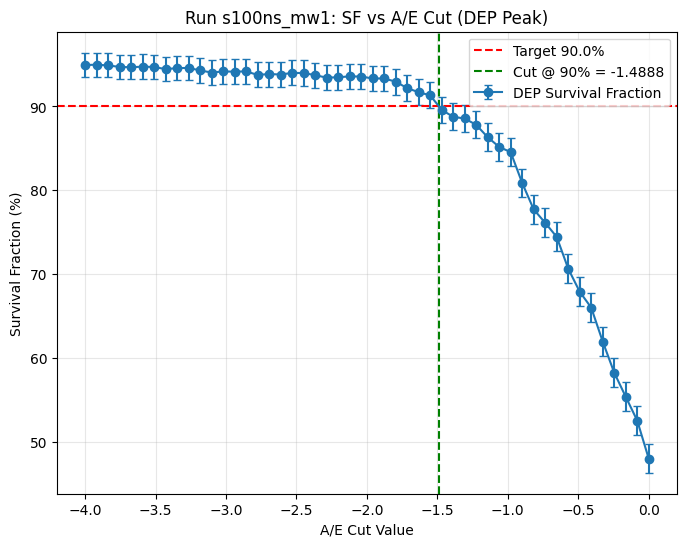

Interpolated cut for 90% SF: -1.488790
Run s100ns_mw1: cut_value_90 = -1.488790, sf_val_dep = 90.327508 ± 1.578039
Calculating survival fraction (Interpolation) for s100ns_mw3 ...
Sampling 50 points from -4 to 0...


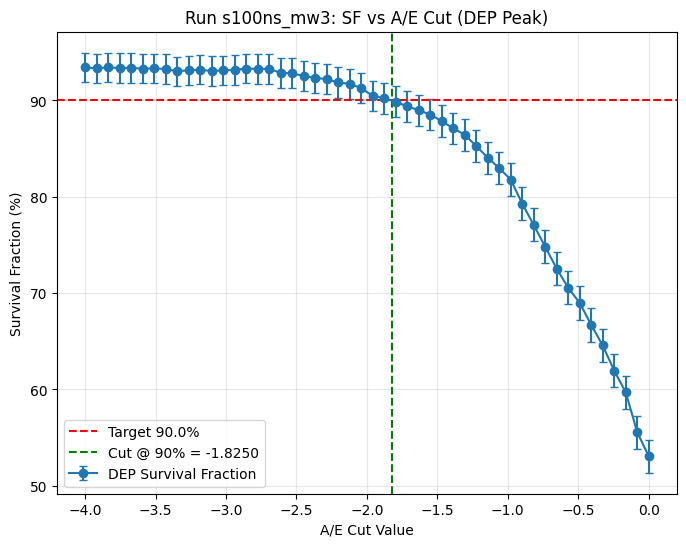

Interpolated cut for 90% SF: -1.825033
Run s100ns_mw3: cut_value_90 = -1.825033, sf_val_dep = 89.828511 ± 1.599430
Calculating survival fraction (Interpolation) for s100ns_mw5 ...
Sampling 50 points from -4 to 0...


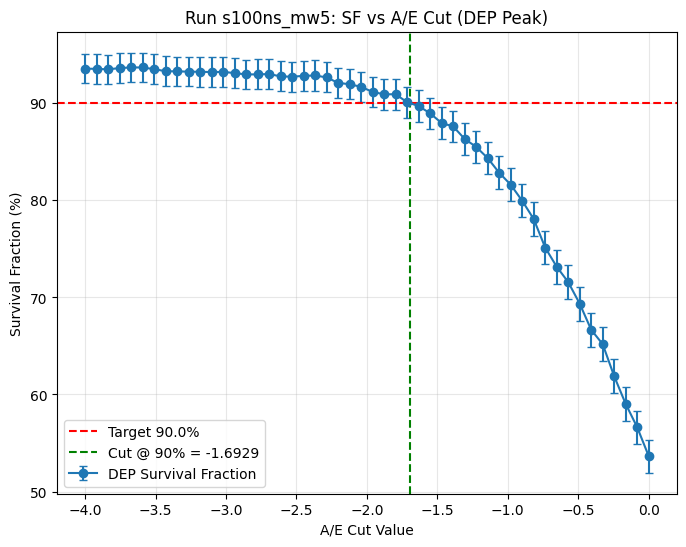

Interpolated cut for 90% SF: -1.692914
Run s100ns_mw5: cut_value_90 = -1.692914, sf_val_dep = 89.991668 ± 1.601232
Calculating survival fraction (Interpolation) for s100ns_mw7 ...
Sampling 50 points from -4 to 0...


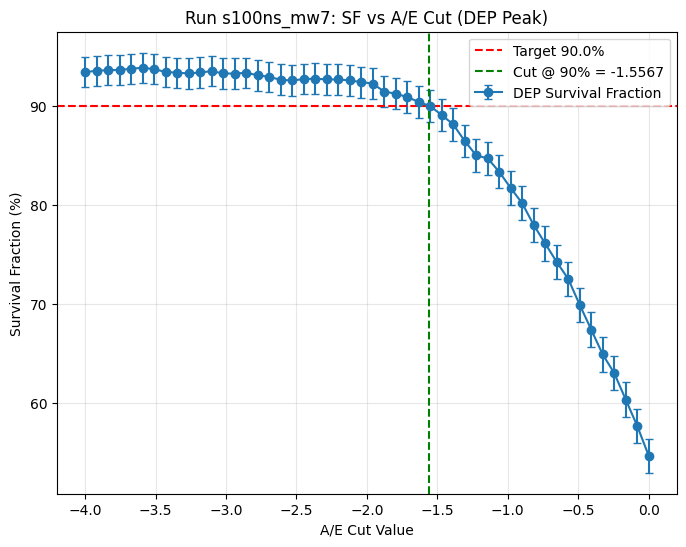

Interpolated cut for 90% SF: -1.556705
Run s100ns_mw7: cut_value_90 = -1.556705, sf_val_dep = 89.940900 ± 1.602300
Calculating survival fraction (Interpolation) for s200ns_mw1 ...
Sampling 50 points from -4 to 0...


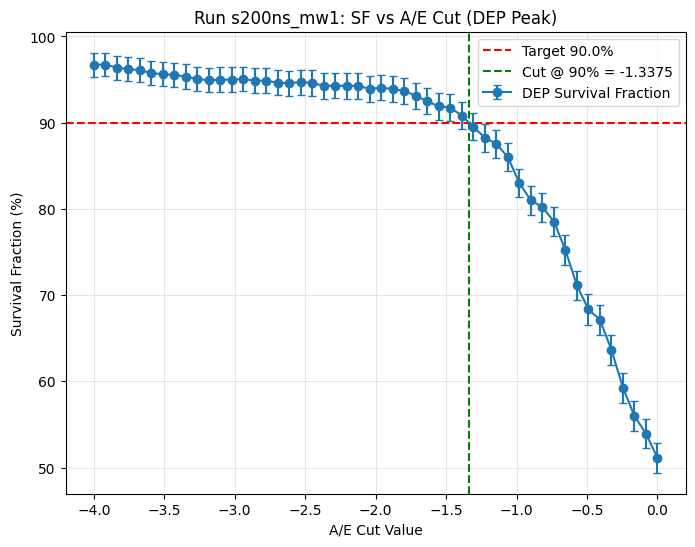

Interpolated cut for 90% SF: -1.337492
Run s200ns_mw1: cut_value_90 = -1.337492, sf_val_dep = 90.175005 ± 1.565304
Calculating survival fraction (Interpolation) for s200ns_mw3 ...
Sampling 50 points from -4 to 0...


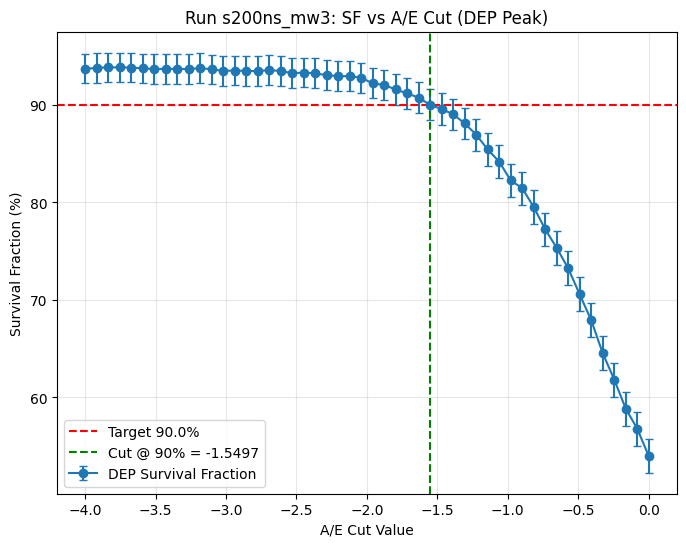

Interpolated cut for 90% SF: -1.549694
Run s200ns_mw3: cut_value_90 = -1.549694, sf_val_dep = 90.006903 ± 1.595705
Calculating survival fraction (Interpolation) for s200ns_mw5 ...
Sampling 50 points from -4 to 0...


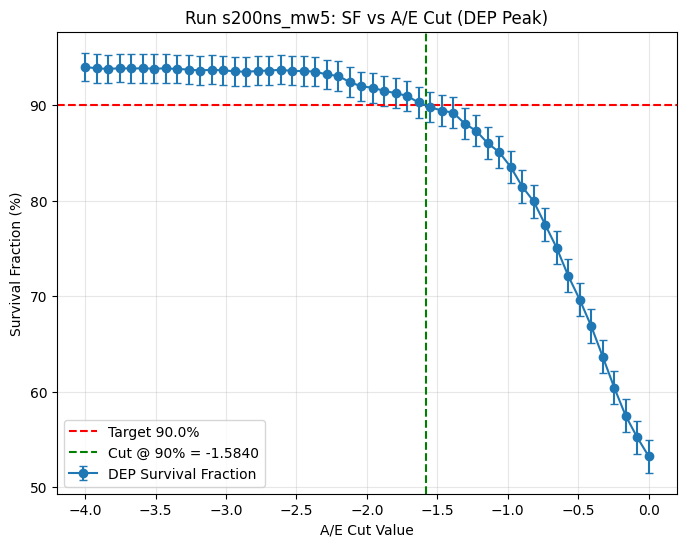

Interpolated cut for 90% SF: -1.583977
Run s200ns_mw5: cut_value_90 = -1.583977, sf_val_dep = 90.054611 ± 1.589781
Calculating survival fraction (Interpolation) for s200ns_mw7 ...
Sampling 50 points from -4 to 0...


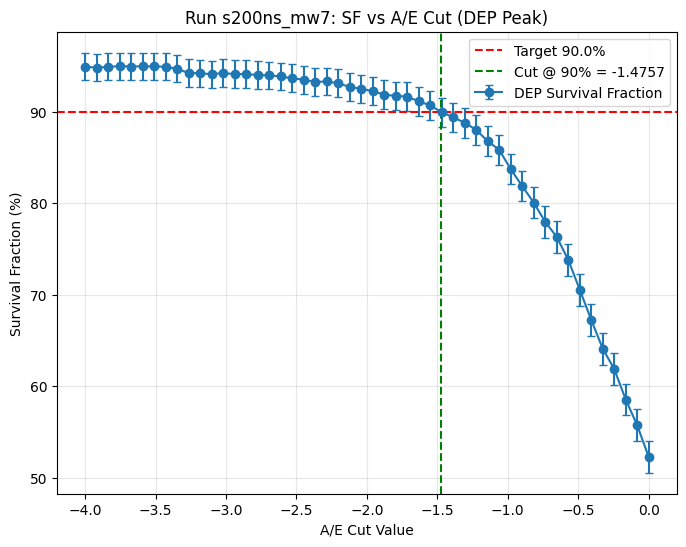

Interpolated cut for 90% SF: -1.475652
Run s200ns_mw7: cut_value_90 = -1.475652, sf_val_dep = 89.931058 ± 1.588559
Calculating survival fraction (Interpolation) for s60ns_mw1 ...
Sampling 50 points from -4 to 0...


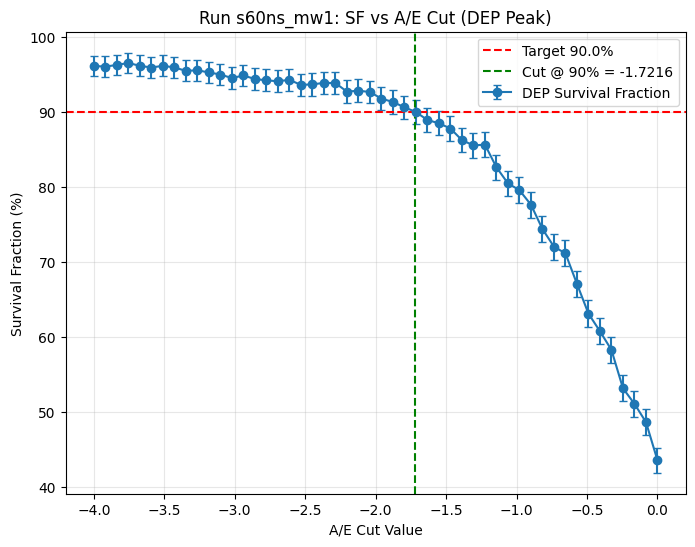

Interpolated cut for 90% SF: -1.721593
Run s60ns_mw1: cut_value_90 = -1.721593, sf_val_dep = 90.083791 ± 1.571095
Calculating survival fraction (Interpolation) for s60ns_mw3 ...
Sampling 50 points from -4 to 0...


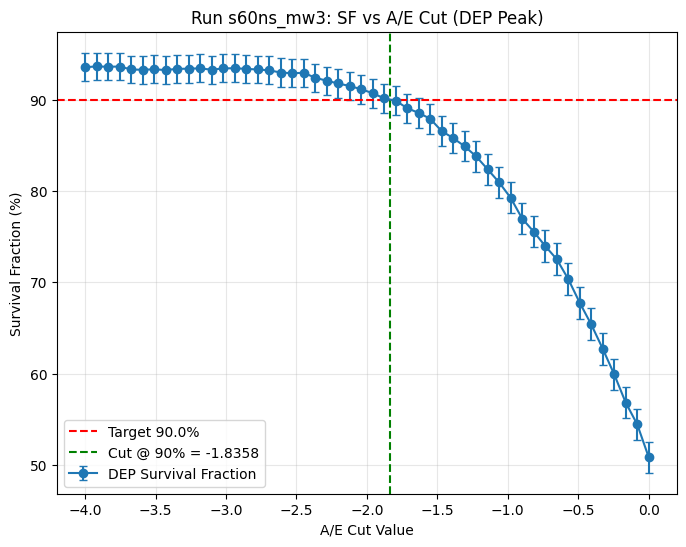

Interpolated cut for 90% SF: -1.835773
Run s60ns_mw3: cut_value_90 = -1.835773, sf_val_dep = 90.000077 ± 1.593674
Calculating survival fraction (Interpolation) for s60ns_mw5 ...
Sampling 50 points from -4 to 0...


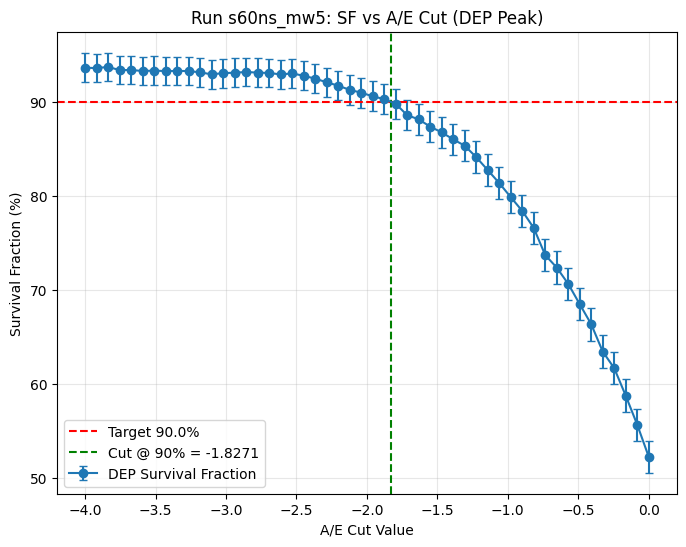

Interpolated cut for 90% SF: -1.827102
Run s60ns_mw5: cut_value_90 = -1.827102, sf_val_dep = 89.912322 ± 1.598406
Calculating survival fraction (Interpolation) for s60ns_mw7 ...
Sampling 50 points from -4 to 0...


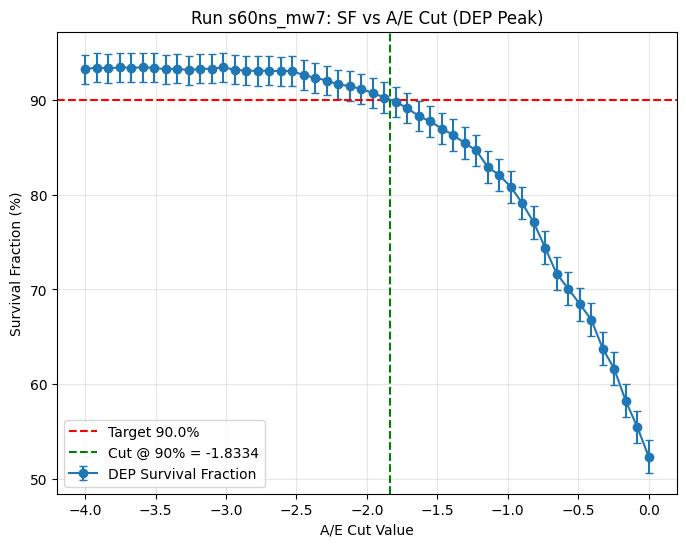

Interpolated cut for 90% SF: -1.833437
Run s60ns_mw7: cut_value_90 = -1.833437, sf_val_dep = 90.000979 ± 1.597200
Calculating survival fraction (Interpolation) for s300ns_mw1 ...
Sampling 50 points from -4 to 0...


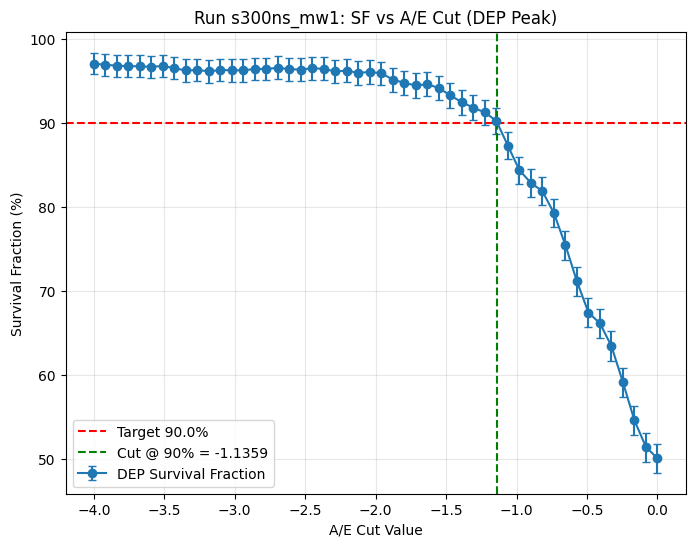

Interpolated cut for 90% SF: -1.135884
Run s300ns_mw1: cut_value_90 = -1.135884, sf_val_dep = 90.051204 ± 1.554289
Calculating survival fraction (Interpolation) for s300ns_mw3 ...
Sampling 50 points from -4 to 0...


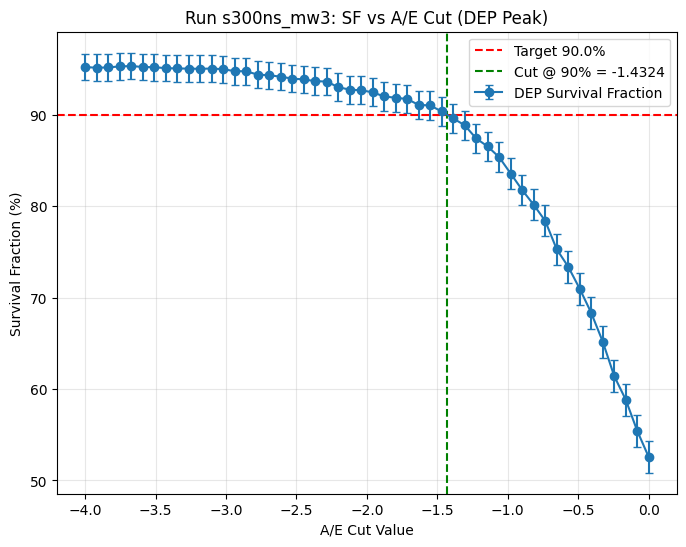

Interpolated cut for 90% SF: -1.432352
Run s300ns_mw3: cut_value_90 = -1.432352, sf_val_dep = 90.170132 ± 1.583909
Calculating survival fraction (Interpolation) for s300ns_mw5 ...
Sampling 50 points from -4 to 0...


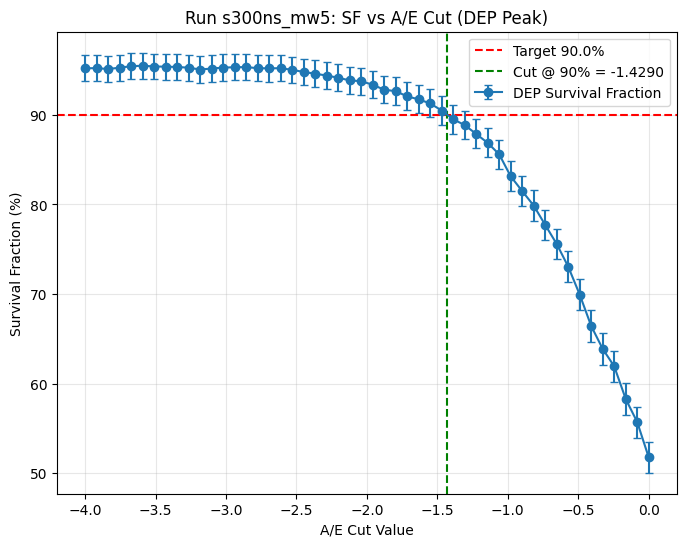

Interpolated cut for 90% SF: -1.429007
Run s300ns_mw5: cut_value_90 = -1.429007, sf_val_dep = 89.947917 ± 1.584261
Calculating survival fraction (Interpolation) for s300ns_mw7 ...
Sampling 50 points from -4 to 0...


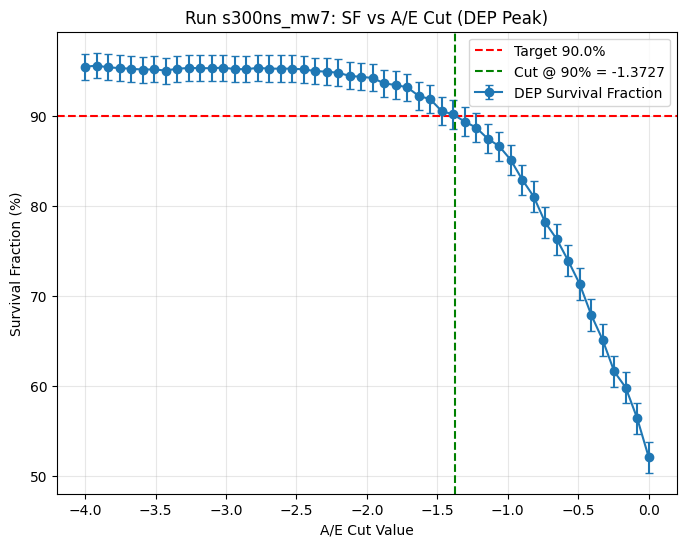

Interpolated cut for 90% SF: -1.372650
Run s300ns_mw7: cut_value_90 = -1.372650, sf_val_dep = 90.024391 ± 1.577470
Calculating survival fraction (Interpolation) for s300ns_mw15 ...
Sampling 50 points from -4 to 0...


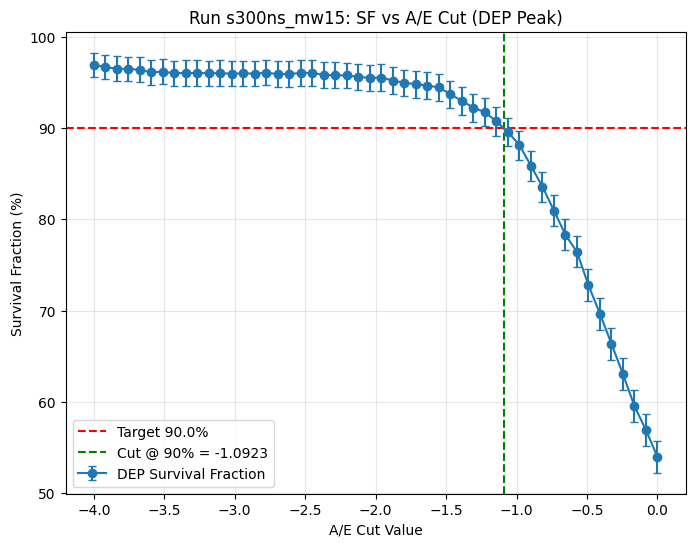

Interpolated cut for 90% SF: -1.092291
Run s300ns_mw15: cut_value_90 = -1.092291, sf_val_dep = 89.816064 ± 1.568015
Calculating survival fraction (Interpolation) for s500ns_mw1 ...
Sampling 50 points from -4 to 0...


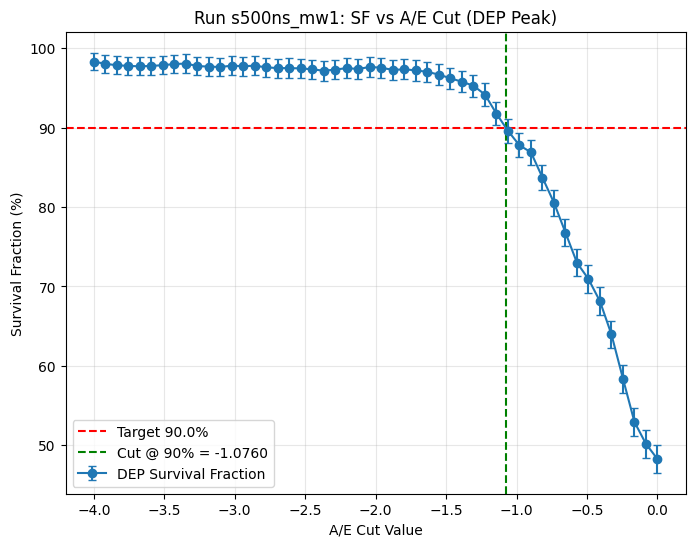

Interpolated cut for 90% SF: -1.075958
Run s500ns_mw1: cut_value_90 = -1.075958, sf_val_dep = 90.060404 ± 1.487704
Calculating survival fraction (Interpolation) for s500ns_mw3 ...
Sampling 50 points from -4 to 0...


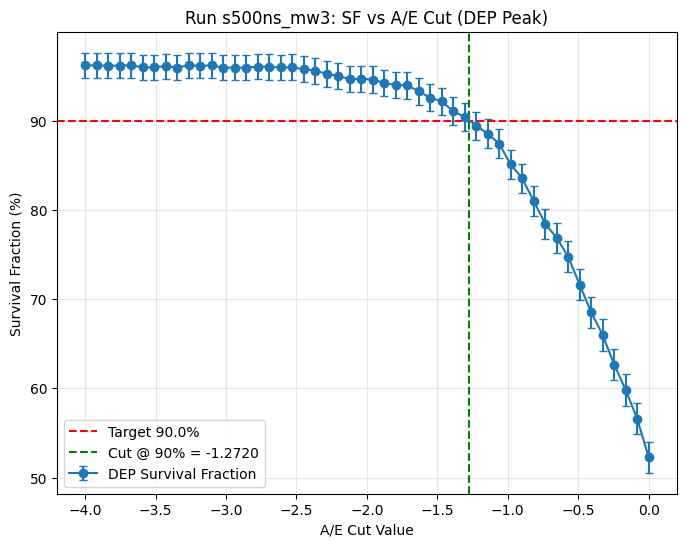

Interpolated cut for 90% SF: -1.272027
Run s500ns_mw3: cut_value_90 = -1.272027, sf_val_dep = 90.142996 ± 1.569491
Calculating survival fraction (Interpolation) for s500ns_mw5 ...
Sampling 50 points from -4 to 0...


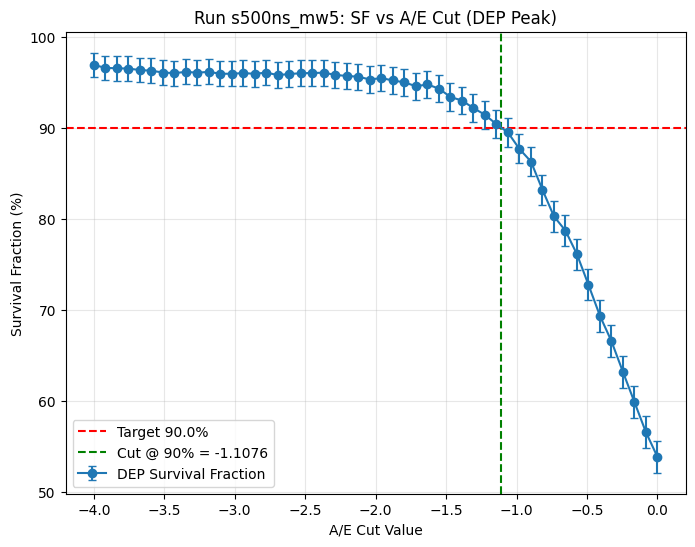

Interpolated cut for 90% SF: -1.107618
Run s500ns_mw5: cut_value_90 = -1.107618, sf_val_dep = 90.154704 ± 1.562475
Calculating survival fraction (Interpolation) for s500ns_mw7 ...
Sampling 50 points from -4 to 0...


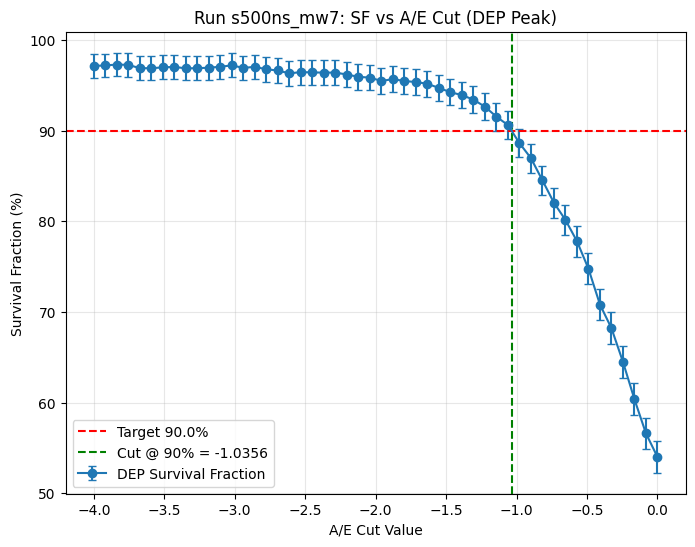

Interpolated cut for 90% SF: -1.035571
Run s500ns_mw7: cut_value_90 = -1.035571, sf_val_dep = 90.179338 ± 1.549611
Calculating survival fraction (Interpolation) for s500ns_mw15 ...
Sampling 50 points from -4 to 0...


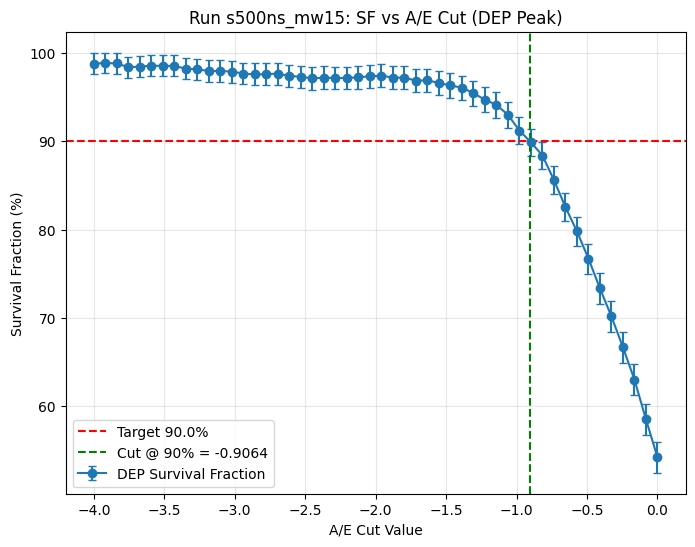

Interpolated cut for 90% SF: -0.906420
Run s500ns_mw15: cut_value_90 = -0.906420, sf_val_dep = 89.834944 ± 1.523936
Calculating survival fraction (Interpolation) for s700ns_mw1 ...
Sampling 50 points from -4 to 0...


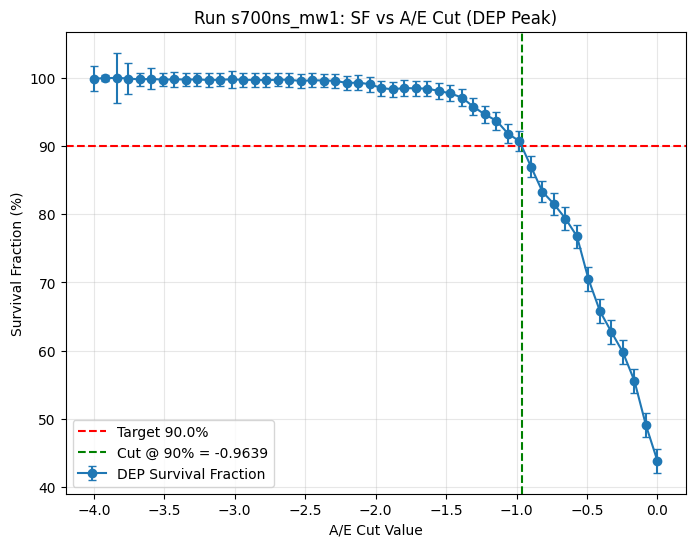

Interpolated cut for 90% SF: -0.963896
Run s700ns_mw1: cut_value_90 = -0.963896, sf_val_dep = 90.151684 ± 1.444220
Calculating survival fraction (Interpolation) for s700ns_mw3 ...
Sampling 50 points from -4 to 0...


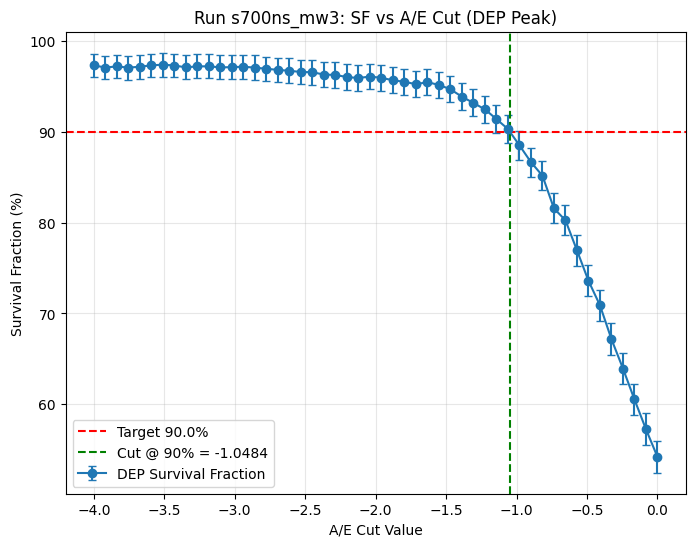

Interpolated cut for 90% SF: -1.048440
Run s700ns_mw3: cut_value_90 = -1.048440, sf_val_dep = 89.830943 ± 1.551757
Calculating survival fraction (Interpolation) for s700ns_mw5 ...
Sampling 50 points from -4 to 0...


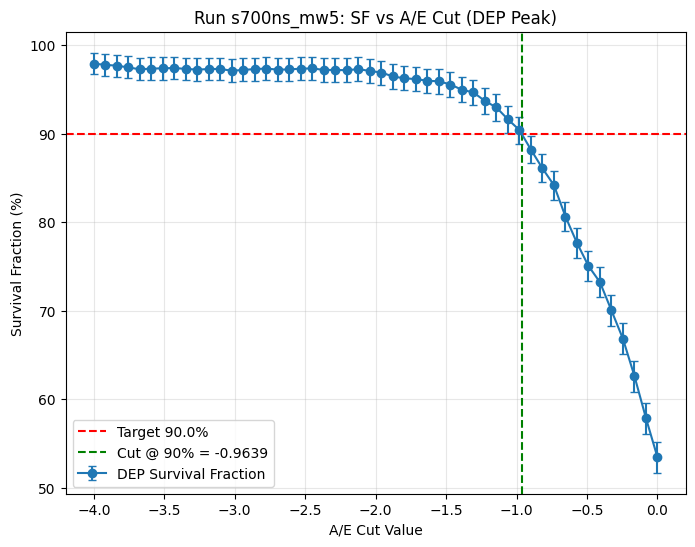

Interpolated cut for 90% SF: -0.963932
Run s700ns_mw5: cut_value_90 = -0.963932, sf_val_dep = 90.000015 ± 1.536114
Calculating survival fraction (Interpolation) for s700ns_mw7 ...
Sampling 50 points from -4 to 0...


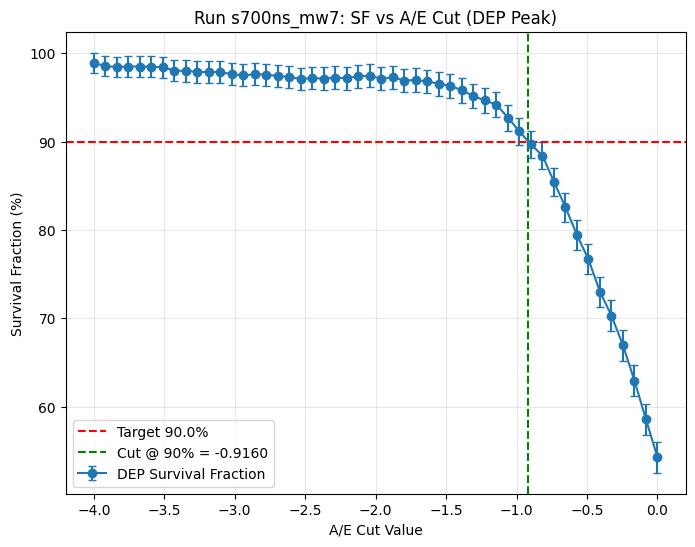

Interpolated cut for 90% SF: -0.915962
Run s700ns_mw7: cut_value_90 = -0.915962, sf_val_dep = 90.020470 ± 1.525068
Calculating survival fraction (Interpolation) for s700ns_mw15 ...
Sampling 50 points from -4 to 0...


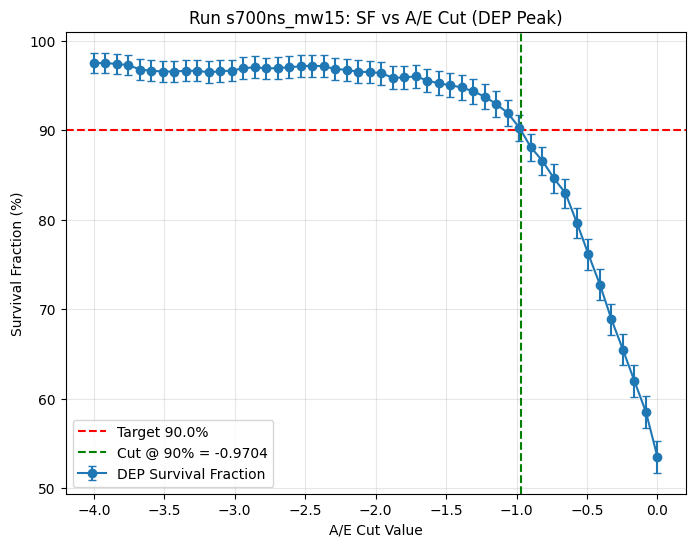

Interpolated cut for 90% SF: -0.970384
Run s700ns_mw15: cut_value_90 = -0.970384, sf_val_dep = 89.934143 ± 1.486727
Calculating survival fraction (Interpolation) for s1000ns_mw1 ...
Sampling 50 points from -4 to 0...


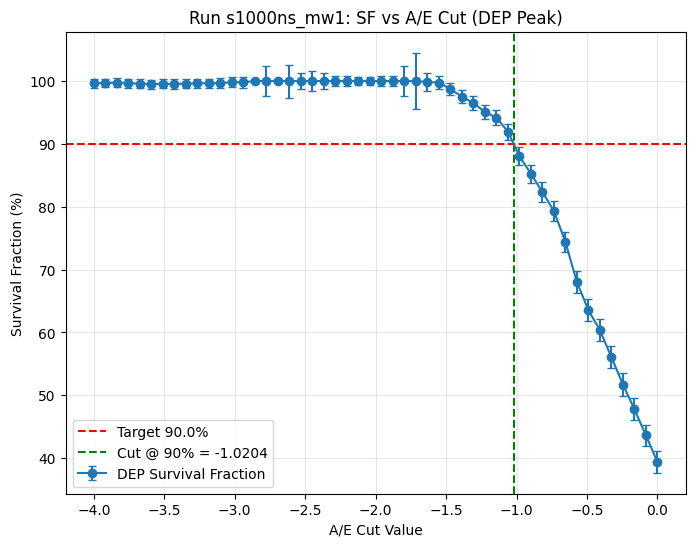

Interpolated cut for 90% SF: -1.020448
Run s1000ns_mw1: cut_value_90 = -1.020448, sf_val_dep = 90.341526 ± 1.339828
Calculating survival fraction (Interpolation) for s1000ns_mw3 ...
Sampling 50 points from -4 to 0...


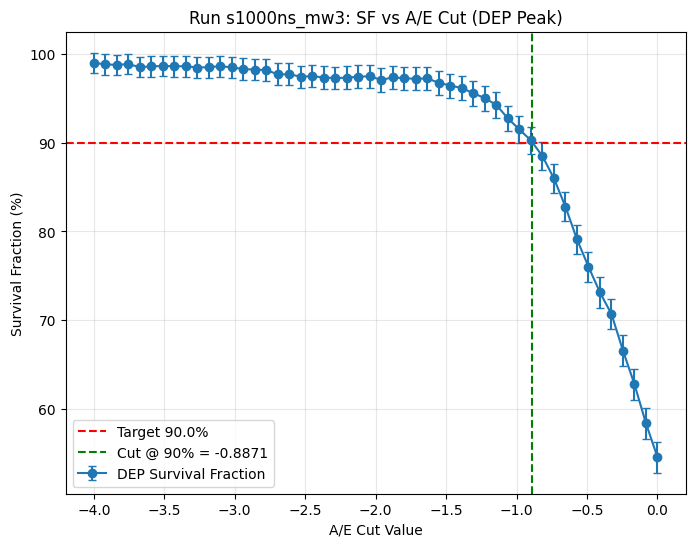

Interpolated cut for 90% SF: -0.887106
Run s1000ns_mw3: cut_value_90 = -0.887106, sf_val_dep = 89.739338 ± 1.520484
Calculating survival fraction (Interpolation) for s1000ns_mw5 ...
Sampling 50 points from -4 to 0...


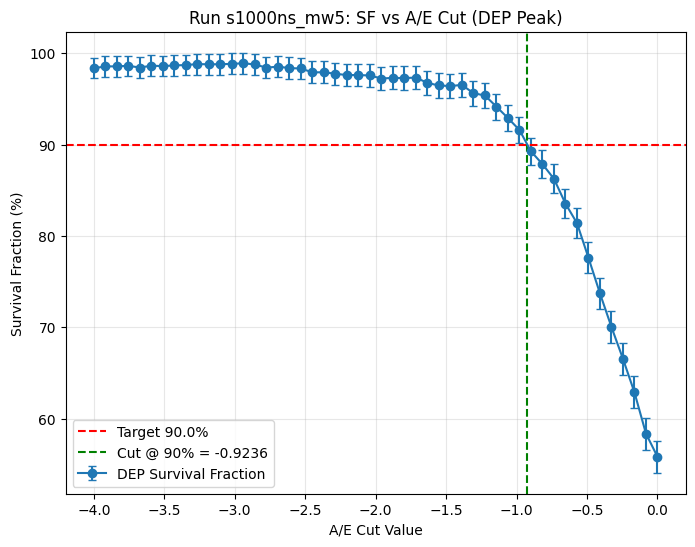

Interpolated cut for 90% SF: -0.923583
Run s1000ns_mw5: cut_value_90 = -0.923583, sf_val_dep = 90.083296 ± 1.496306
Calculating survival fraction (Interpolation) for s1000ns_mw7 ...
Sampling 50 points from -4 to 0...


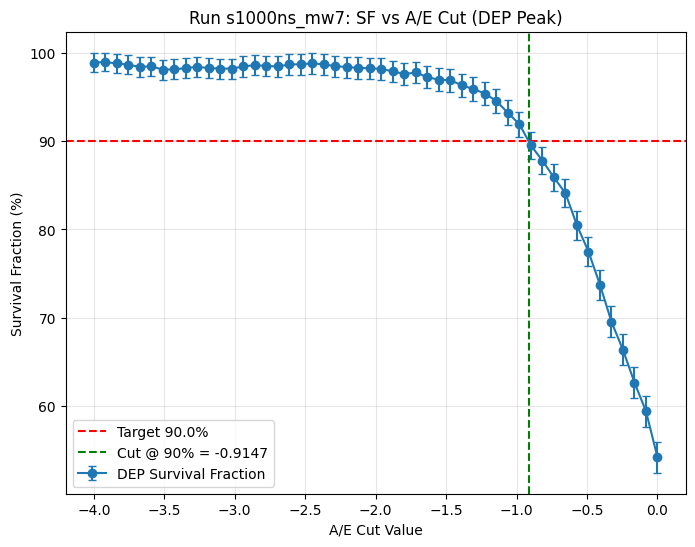

Interpolated cut for 90% SF: -0.914689
Run s1000ns_mw7: cut_value_90 = -0.914689, sf_val_dep = 89.784013 ± 1.479781
Calculating survival fraction (Interpolation) for s1000ns_mw15 ...
Sampling 50 points from -4 to 0...


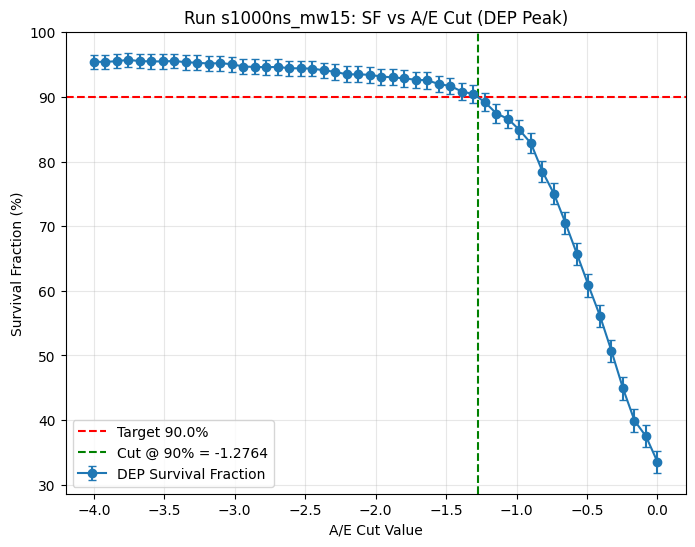

Interpolated cut for 90% SF: -1.276407
Run s1000ns_mw15: cut_value_90 = -1.276407, sf_val_dep = 90.340378 ± 1.349005
Calculating survival fraction (Interpolation) for s2000ns_mw3 ...
Sampling 50 points from -4 to 0...


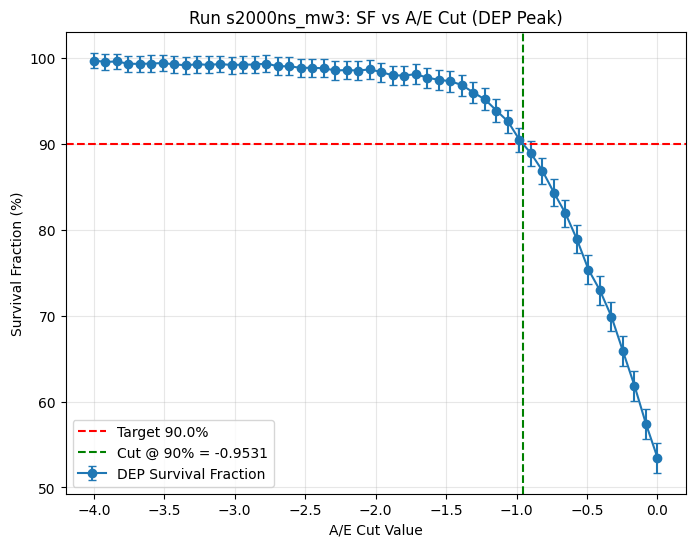

Interpolated cut for 90% SF: -0.953096
Run s2000ns_mw3: cut_value_90 = -0.953096, sf_val_dep = 89.915364 ± 1.431092
Calculating survival fraction (Interpolation) for s2000ns_mw5 ...
Sampling 50 points from -4 to 0...


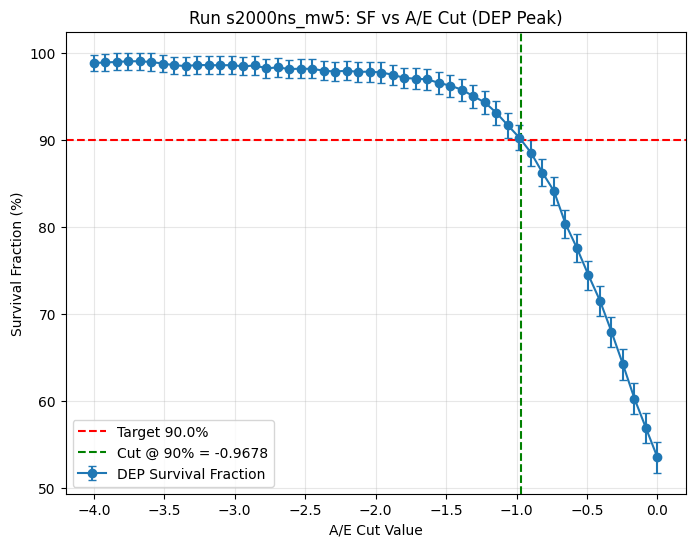

Interpolated cut for 90% SF: -0.967756
Run s2000ns_mw5: cut_value_90 = -0.967756, sf_val_dep = 90.170430 ± 1.444808
Calculating survival fraction (Interpolation) for s2000ns_mw7 ...
Sampling 50 points from -4 to 0...


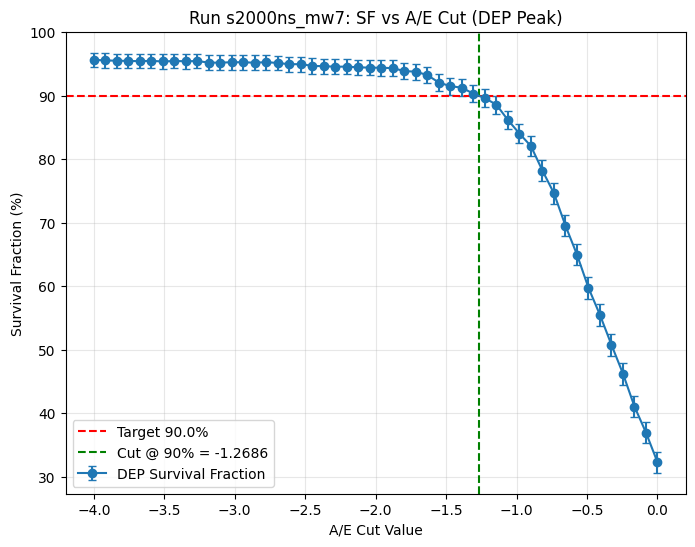

Interpolated cut for 90% SF: -1.268556
Run s2000ns_mw7: cut_value_90 = -1.268556, sf_val_dep = 89.890746 ± 1.374040


In [11]:
sep_sfs = {};fep_sfs = {};dep_sfs = {};cut_value_90s = {};cut_value_90s_err  = {}
for run in runs:
    cut_value_90,  cut_value_90_err, sf_val_dep, sf_err_dep, sf_val_sep, sf_err_sep, sf_val_fep, sf_err_fep = get_sf_from_run_linear_interpolation(run)
    sep_sfs[run] = (sf_val_sep, sf_err_sep)
    fep_sfs[run] = (sf_val_fep, sf_err_fep)
    dep_sfs[run] = (sf_val_dep, sf_err_dep)
    cut_value_90s[run] = cut_value_90
    cut_value_90s_err[run] = cut_value_90_err
    print(f"Run {run}: cut_value_90 = {cut_value_90:.6f}, sf_val_dep = {sf_val_dep:.6f} ± {sf_err_dep:.6f}")

In [12]:
import pickle
from pathlib import Path
fitrange_dep = (1565, 1615)
peak_dep = 1592.5
fitrange_fep =  (2580, 2645)
peak_fep = 2614.5
fitrange_sep = (2070, 2140)
peak_sep =2103.5
sf_results = {
    "meta": {
        "target_dep_sf": 90,
        "runs": list(runs),
        "channel": "ch002",
        "energy_field": energy_field,
        "aoe_field": aoe_field,
        "fitrange_dep": fitrange_dep,
        "peak_dep": peak_dep,
        "fitrange_sep": fitrange_sep,
        "peak_sep": peak_sep,
        "fitrange_fep": fitrange_fep,
        "peak_fep": peak_fep,
    },
    "cut_value_90": cut_value_90s,
    "cut_value_90_err":cut_value_90s_err,
    "dep_sfs": dep_sfs,
    "sep_sfs": sep_sfs,
    "fep_sfs": fep_sfs,
}

In [13]:
outpath = Path("sf_results_cut90_linear_interpolation_all_50points.pkl")

with open(outpath, "wb") as f:
    pickle.dump(sf_results, f)

print("saved to:", outpath.resolve())

saved to: /mnt/atlas02/users/leoli/SEP_analysis/sf_results_cut90_linear_interpolation_all_50points.pkl


In [ ]:
import pickle
sf_results = load_pkl("sf_results_cut90_linear_interpolation_all.pkl")


In [ ]:
plot_heatmap(sf_results)

In [ ]:
import pickle


## read cutvalue and plot

In [ ]:
path = "sf_results_cut90_linear_interpolation.pkl"
with open(path, "rb") as f:
    sf_results = pickle.load(f)
sf_results.keys()


In [ ]:
cut_values = sf_results['cut_value_90']
cut_errors = sf_results['cut_value_90_err']
cut_values, cut_errors

In [ ]:
for run in runs:
    cut_value = cut_values[run]
    cut_error = cut_errors[run]
    print(f"Run {run}: cut_value_90 = {cut_value:.6f} ± {cut_error:.6f}")
    sf_val_dep, sf_err_dep, values_dep, errors_dep = sf.get_survival_fraction(
        energy=E_fit_dep,
        cut_param=aoe_fit_dep,
        cut_val=cut_value,
        peak=peak_dep,        # DEP peak
        fit_range=fitrange_dep,
        func=sf.hpge_peak,
        mode="greater",
        display=2,
        eres_pars=3
    )
    print("survival fraction dep =", sf_val_dep)
    print("survival fraction error =", sf_err_dep)

    sf_val_sep, sf_err_sep, values_sep, errors_sep = sf.get_survival_fraction(
        energy=E_fit_sep,
        cut_param=aoe_fit_sep,
        cut_val=cut_value,      
        peak=peak_sep,        # SEP peak
        fit_range=fitrange_sep,
        func=sf.hpge_peak,
        mode="greater",
        display=2,
        eres_pars=3
    )
    print("survival fraction sep=", sf_val_sep)
    print("survival fraction error =", sf_err_sep) 

    sf_val_fep, sf_err_fep, values_fep, errors_fep = sf.get_survival_fraction(
        energy=E_fit_fep,
        cut_param=aoe_fit_fep,
        cut_val=cut_value,      
        peak=peak_fep,        # FEP peak
        fit_range=fitrange_fep,
        func=sf.hpge_peak,
        mode="greater",
        display=2,
        eres_pars=3
    )
    print("survival fraction fep=", sf_val_fep)
    print("survival fraction error =", sf_err_fep)    